In [ ]:
# load mnist

# set up CV data splits

# run NMF (k: 5 - 25) + LR

# run SNMF (k: 5 - 24) Lc = 0.1

# compare performance (accuracy, reconstruction error, stability)


In [9]:
import snmf_sklearn, inspect, importlib, sys
print("Imported from:", snmf_sklearn.__file__)
print("Has CoreNMF symbol?", hasattr(snmf_sklearn, "CoreNMF"))
print("Snippet:", inspect.getsource(snmf_sklearn)[:300])  # sanity check


Imported from: /Users/sande/Documents/GitHub/SNMF/results/analysis/MNIST/snmf_sklearn.py
Has CoreNMF symbol? False
Snippet: import numpy as np
import torch
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.validation import check_is_fitted

# ---- import your core class ----
from SNMF.nmf_cpu import NMF as CoreNMF


# ---- small sa


In [11]:
# --- FAST NMF → SNMF WARM-START PIPELINE ---

import numpy as np
from sklearn.decomposition import NMF as SKNMF
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
import importlib, snmf_sklearn
snmf_sklearn = importlib.reload(snmf_sklearn)
SNMFClassifier = snmf_sklearn.SNMFClassifier


# ---------- 1) Baseline unsupervised NMF ----------
def run_unsup(k, X_train, y_train, X_test, y_test, nmf_max_iter=300, seed=42):
    nmf = SKNMF(n_components=k, init='nndsvda', random_state=seed, max_iter=nmf_max_iter)
    Ztr = nmf.fit_transform(X_train)     # (n_train, k)
    Zte = nmf.transform(X_test)          # (n_test, k)
    clf = LogisticRegression(max_iter=500)
    clf.fit(Ztr, y_train)
    acc = accuracy_score(y_test, clf.predict(Zte))

    # reconstruction errors (relative Frobenius)
    rec_train = nmf.reconstruction_err_ / (np.linalg.norm(X_train, 'fro') + 1e-30)
    Xhat_test = Zte @ nmf.components_    # reconstruct test
    rec_test = np.linalg.norm(X_test - Xhat_test, 'fro') / (np.linalg.norm(X_test, 'fro') + 1e-30)

    return acc, rec_train, rec_test, nmf


# ---------- 2) Warm-started SNMF (fast) ----------
def run_snmf_warm(k, X_train, y_train, X_test, y_test,
                  subset_train=20000,               # use a 10k stratified subset to fit quickly
                  nmf_warm_max_iter=200,            # how long to pretrain unsup NMF
                  lambda_c=0.1, lambda_p=1e-3, lr=0.003,
                  max_iterations=20000, min_iterations=300,
                  tolerance=1e-6, tolerance_ce=5e-2,
                  test_conv=200, report_loss=500,
                  seed=42):

    # 2a) NMF warm start on the same (sub)set used for SNMF fit
    if subset_train and subset_train < len(X_train):
        sss = StratifiedShuffleSplit(n_splits=1, train_size=subset_train, random_state=seed)
        idx_small, _ = next(sss.split(X_train, y_train))
        X_small, y_small = X_train[idx_small], y_train[idx_small]
    else:
        X_small, y_small = X_train, y_train

    nmf0 = SKNMF(n_components=k, init="nndsvda", max_iter=nmf_warm_max_iter, random_state=seed)
    Z_small = nmf0.fit_transform(X_small)  # (Ns, k)
    W0 = nmf0.components_.T                # (F, k)
    H0 = Z_small.T                         # (k, Ns)

    # 2b) Build & fit SNMF from the warm start
    snmf = SNMFClassifier(
        n_components=k,
        lambda_c=lambda_c,
        lambda_p=lambda_p,
        lr=lr,
        max_iterations=max_iterations,
        min_iterations=min_iterations,
        tolerance=tolerance,
        tolerance_ce=tolerance_ce,
        test_conv=test_conv,
        report_loss=report_loss,
        random_state=seed,
        beta=2,
        supervised=True,
        init_method="random",
    )

    # Use the wrapper's internal helpers to construct the core, then inject W/H/B and fit.
    Xs, Ys = snmf._check_Xy(X_small, y_small)
    V, Yc = snmf._to_core_shapes(Xs, Ys)

    # Import the core class here to avoid circular import issues
    from SNMF.nmf_cpu import NMF as CoreNMF
    import torch
    rng = np.random.default_rng(seed)

    snmf.core_ = CoreNMF(
        V=torch.from_numpy(V),
        Y=torch.from_numpy(Yc),
        rank=k,
        lambda_c=lambda_c,
        lambda_p=lambda_p,
        lr=lr,
        report_loss=report_loss,
        max_iterations=max_iterations,
        tolerance=tolerance,
        tolerance_ce=tolerance_ce,
        test_conv=test_conv,
        init_method="random",
        floating_point_precision="double",
        min_iterations=min_iterations,
        generator=rng,
    )

    # early stopping knobs (patch A)
    snmf.core_._patience = 2         # stop after 4 windows without progress
    snmf.core_._es_window = 200        # window size (iterations)
    snmf.core_._rel_improve_min = 1e-3 # min relative improvement per window

    # faster refit during transform/predict (patch B)
    snmf.core_._refit_max_iter = 500
    snmf.core_._refit_min_iter = 30


    # Warm start: set W/H from unsup NMF; small random B
    snmf.core_._W = torch.from_numpy(W0[None, :, :]).type(snmf.core_._tensor_type)
    snmf.core_._H = torch.from_numpy(H0[None, :, :]).type(snmf.core_._tensor_type)
    C = len(np.unique(y_train))
    B0 = 1e-3 * rng.standard_normal((C, k))
    snmf.core_._B = torch.from_numpy(B0[None, :, :]).type(snmf.core_._tensor_type)
    
    # Fit supervised from this warm start (on the subset)
    snmf.core_.fit(beta=2, supervised=True)

    # Pull parameters and finalize the wrapper state
    snmf.W_ = snmf.core_.W.detach().cpu().numpy()[0]
    snmf.H_ = snmf.core_.H.detach().cpu().numpy()[0]
    snmf.B_ = snmf.core_.B.detach().cpu().numpy()[0]
    snmf.classes_ = np.unique(y_train)
    snmf.history_ = dict(snmf.core_.results)
    snmf.converged_at_ = int(getattr(snmf.core_, "_conv", 0))

    # Evaluate accuracy
    y_pred = snmf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # --- reconstruction errors ---
    # training
    Xhat_train = snmf.H_.T @ snmf.W_.T   # careful: shapes (K,N)T x (K,F)T? check orientation
    rec_train = np.linalg.norm(X_train - Xhat_train, 'fro') / (np.linalg.norm(X_train, 'fro') + 1e-30)

    # test: refit H on X_test with fixed W
    Htest = snmf.transform(X_test)       # (N_test, K)
    Xhat_test = Htest @ snmf.W_.T
    rec_test = np.linalg.norm(X_test - Xhat_test, 'fro') / (np.linalg.norm(X_test, 'fro') + 1e-30)

    return acc, rec_train, rec_test, snmf

In [5]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(56000, 784) (56000,)
(14000, 784) (14000,)


In [6]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import NMF as SKNMF
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

import importlib, snmf_sklearn
importlib.reload(snmf_sklearn)
from snmf_sklearn import SNMFClassifier  # this now grabs the reloaded class

# Load MNIST
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X = (X / 255.0).astype(np.float64)
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

FRACTION = 0.1   # use 10% of the training set
sss = StratifiedShuffleSplit(n_splits=1, train_size=FRACTION, random_state=42)
idx_small, _ = next(sss.split(X_train, y_train))

X_train_small = X_train[idx_small]
y_train_small = y_train[idx_small]

print("Train small:", X_train_small.shape, y_train_small.shape)
print("Test full :", X_test.shape, y_test.shape)



Train small: (5600, 784) (5600,)
Test full : (14000, 784) (14000,)


In [20]:
rows = []
for k in range(3, 30):
    # unsupervised baseline
    u_acc, u_rec_tr, u_rec_te, _ = run_unsup(k, X_train_small, y_train_small, X_test, y_test)
    print(f"{k:2d} | {u_acc:7.4f} | {u_rec_te:7.4f} | ", end="\n")

    # supervised SNMF
    s_acc, s_rec_tr, s_rec_te, _ = run_snmf_warm(
        k, X_train_small, y_train_small, X_test, y_test,
        lambda_c=0.1
    )

    rows.append((k, u_acc, u_rec_tr, u_rec_te, s_acc, s_rec_tr, s_rec_te))

    print(
        f"{k:2d} | "
        f"U-acc={u_acc:7.4f}  U-rec_tr={u_rec_tr:7.4f}  U-rec_te={u_rec_te:7.4f} | "
        f"S-acc={s_acc:7.4f}  S-rec_tr={s_rec_tr:7.4f}  S-rec_te={s_rec_te:7.4f}"
    )


 3 |  0.4677 |  0.6916 | 
Epoch: 0 ; Ltot = 1989.58 ;  Lrec = 700.04 ; Lce = 12895.45 ; acc = 0.081
Epoch: 100 ; Ltot = 1267.66 ;  Lrec = 486.21 ; Lce = 7814.50 ; acc = 0.457
Epoch: 0 ; Ltot = 1264.50 ;  Lrec = 486.21 ; Lce = 7782.88 ; acc = 0.457
Epoch: 100 ; Ltot = 1263.72 ;  Lrec = 486.21 ; Lce = 7775.09 ; acc = 0.457
Epoch: 200 ; Ltot = 1263.43 ;  Lrec = 486.21 ; Lce = 7772.21 ; acc = 0.457
Epoch: 300 ; Ltot = 1263.31 ;  Lrec = 486.21 ; Lce = 7770.97 ; acc = 0.457
 3 | U-acc= 0.4677  U-rec_tr= 0.6929  U-rec_te= 0.6916 | S-acc= 0.4594  S-rec_tr= 0.6929  S-rec_te= 0.6916
 4 |  0.4885 |  0.6696 | 
Epoch: 0 ; Ltot = 1989.23 ;  Lrec = 699.74 ; Lce = 12894.86 ; acc = 0.104
Epoch: 100 ; Ltot = 1206.20 ;  Lrec = 470.83 ; Lce = 7353.68 ; acc = 0.487
Epoch: 0 ; Ltot = 1202.72 ;  Lrec = 470.83 ; Lce = 7318.96 ; acc = 0.488
Epoch: 100 ; Ltot = 1201.96 ;  Lrec = 470.83 ; Lce = 7311.35 ; acc = 0.488
Epoch: 200 ; Ltot = 1201.71 ;  Lrec = 470.83 ; Lce = 7308.87 ; acc = 0.488
Epoch: 300 ; Ltot = 12

/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


 6 |  0.6375 |  0.6361 | 


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Epoch: 0 ; Ltot = 1988.53 ;  Lrec = 699.11 ; Lce = 12894.12 ; acc = 0.103
Epoch: 100 ; Ltot = 1005.12 ;  Lrec = 447.00 ; Lce = 5581.21 ; acc = 0.654
Epoch: 0 ; Ltot = 993.61 ;  Lrec = 447.00 ; Lce = 5466.12 ; acc = 0.659
Epoch: 100 ; Ltot = 990.71 ;  Lrec = 446.99 ; Lce = 5437.18 ; acc = 0.659
Epoch: 200 ; Ltot = 989.71 ;  Lrec = 446.99 ; Lce = 5427.23 ; acc = 0.660
Epoch: 300 ; Ltot = 989.32 ;  Lrec = 446.99 ; Lce = 5423.30 ; acc = 0.660
Epoch: 0 ; Ltot = 989.15 ;  Lrec = 446.99 ; Lce = 5421.61 ; acc = 0.661
Epoch: 100 ; Ltot = 989.07 ;  Lrec = 446.99 ; Lce = 5420.83 ; acc = 0.661
Epoch: 200 ; Ltot = 989.04 ;  Lrec = 446.99 ; Lce = 5420.48 ; acc = 0.661
Epoch: 300 ; Ltot = 989.02 ;  Lrec = 446.99 ; Lce = 5420.32 ; acc = 0.661
Epoch: 400 ; Ltot = 989.01 ;  Lrec = 446.99 ; Lce = 5420.26 ; acc = 0.661
Epoch: 500 ; Ltot = 989.01 ;  Lrec = 446.99 ; Lce = 5420.24 ; acc = 0.661
Epoch: 0 ; Ltot = 989.01 ;  Lrec = 446.99 ; Lce = 5420.25 ; acc = 0.661
Epoch: 100 ; Ltot = 989.02 ;  Lrec = 446.99

...

Epoch: 0 ; Ltot = 1987.39 ;  Lrec = 697.93 ; Lce = 12894.53 ; acc = 0.105
Epoch: 100 ; Ltot = 827.79 ;  Lrec = 330.99 ; Lce = 4968.10 ; acc = 0.797
Epoch: 0 ; Ltot = 749.26 ;  Lrec = 330.97 ; Lce = 4182.90 ; acc = 0.825
Epoch: 100 ; Ltot = 720.46 ;  Lrec = 330.96 ; Lce = 3894.99 ; acc = 0.837
Epoch: 200 ; Ltot = 706.56 ;  Lrec = 330.96 ; Lce = 3755.99 ; acc = 0.842
Epoch: 300 ; Ltot = 698.99 ;  Lrec = 330.96 ; Lce = 3680.30 ; acc = 0.846
Epoch: 0 ; Ltot = 694.57 ;  Lrec = 330.96 ; Lce = 3636.11 ; acc = 0.848
Epoch: 100 ; Ltot = 691.87 ;  Lrec = 330.96 ; Lce = 3609.11 ; acc = 0.849
Epoch: 200 ; Ltot = 690.17 ;  Lrec = 330.96 ; Lce = 3592.08 ; acc = 0.850
Epoch: 300 ; Ltot = 689.07 ;  Lrec = 330.96 ; Lce = 3581.07 ; acc = 0.850
Epoch: 400 ; Ltot = 688.34 ;  Lrec = 330.96 ; Lce = 3573.81 ; acc = 0.851
Epoch: 500 ; Ltot = 687.85 ;  Lrec = 330.96 ; Lce = 3568.94 ; acc = 0.851
Epoch: 0 ; Ltot = 687.52 ;  Lrec = 330.96 ; Lce = 3565.63 ; acc = 0.852
Epoch: 100 ; Ltot = 687.30 ;  Lrec = 330.96 

/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


29 |  0.6593 |  0.4672 | 


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Epoch: 0 ; Ltot = 1987.22 ;  Lrec = 697.76 ; Lce = 12894.60 ; acc = 0.073
Epoch: 100 ; Ltot = 823.87 ;  Lrec = 328.23 ; Lce = 4956.42 ; acc = 0.800
Epoch: 0 ; Ltot = 744.22 ;  Lrec = 328.20 ; Lce = 4160.24 ; acc = 0.827
Epoch: 100 ; Ltot = 715.51 ;  Lrec = 328.19 ; Lce = 3873.23 ; acc = 0.839
Epoch: 200 ; Ltot = 701.79 ;  Lrec = 328.18 ; Lce = 3736.10 ; acc = 0.845
Epoch: 300 ; Ltot = 694.38 ;  Lrec = 328.17 ; Lce = 3662.01 ; acc = 0.848
Epoch: 0 ; Ltot = 690.10 ;  Lrec = 328.17 ; Lce = 3619.24 ; acc = 0.850
Epoch: 100 ; Ltot = 687.51 ;  Lrec = 328.17 ; Lce = 3593.45 ; acc = 0.851
Epoch: 200 ; Ltot = 685.90 ;  Lrec = 328.17 ; Lce = 3577.27 ; acc = 0.851
Epoch: 300 ; Ltot = 684.86 ;  Lrec = 328.17 ; Lce = 3566.88 ; acc = 0.851
Epoch: 400 ; Ltot = 684.18 ;  Lrec = 328.17 ; Lce = 3560.11 ; acc = 0.852
Epoch: 500 ; Ltot = 683.73 ;  Lrec = 328.17 ; Lce = 3555.64 ; acc = 0.852
Epoch: 0 ; Ltot = 683.43 ;  Lrec = 328.17 ; Lce = 3552.64 ; acc = 0.853
Epoch: 100 ; Ltot = 683.23 ;  Lrec = 328.17 

In [ ]:
# rows = []
# for k in range(5, 25):
#     u_acc, u_rec, _ = run_unsup(k, X_train_small, y_train_small, X_test, y_test)
#     print(f"{k:2d} | {u_acc:7.4f} | {u_rec:7.4f} | ", end="\n")
#     s_acc, s_rec, _ = run_snmf_warm(k, X_train_small, y_train_small, X_test, y_test, lambda_c=0.1)
#     rows.append((k, u_acc, u_rec, s_acc, s_rec))
#     print(f"{k:2d} | {u_acc:7.4f} | {u_rec:7.4f} | {s_acc:8.4f} | {s_rec:8.4f}")


 5 |  0.5891 | 457.9147 | 
Epoch: 0 ; Ltot = 1988.93 ;  Lrec = 699.43 ; Lce = 12894.98 ; acc = 0.060
Epoch: 100 ; Ltot = 1065.01 ;  Lrec = 457.92 ; Lce = 6070.96 ; acc = 0.603
Epoch: 0 ; Ltot = 1056.84 ;  Lrec = 457.91 ; Lce = 5989.23 ; acc = 0.607
Epoch: 100 ; Ltot = 1054.72 ;  Lrec = 457.91 ; Lce = 5968.06 ; acc = 0.607
Epoch: 200 ; Ltot = 1053.92 ;  Lrec = 457.91 ; Lce = 5960.06 ; acc = 0.607
Epoch: 300 ; Ltot = 1053.56 ;  Lrec = 457.91 ; Lce = 5956.49 ; acc = 0.607
Epoch: 0 ; Ltot = 1053.39 ;  Lrec = 457.91 ; Lce = 5954.72 ; acc = 0.608
Epoch: 100 ; Ltot = 1053.29 ;  Lrec = 457.91 ; Lce = 5953.79 ; acc = 0.608
Epoch: 200 ; Ltot = 1053.24 ;  Lrec = 457.91 ; Lce = 5953.27 ; acc = 0.608
Epoch: 300 ; Ltot = 1053.21 ;  Lrec = 457.91 ; Lce = 5952.98 ; acc = 0.608
Epoch: 400 ; Ltot = 1053.20 ;  Lrec = 457.91 ; Lce = 5952.80 ; acc = 0.608
Epoch: 500 ; Ltot = 1053.18 ;  Lrec = 457.91 ; Lce = 5952.70 ; acc = 0.608
Epoch: 0 ; Ltot = 1053.18 ;  Lrec = 457.91 ; Lce = 5952.64 ; acc = 0.608
Epoch

/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


 6 |  0.6375 | 446.9243 | 


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Epoch: 0 ; Ltot = 1988.53 ;  Lrec = 699.11 ; Lce = 12894.12 ; acc = 0.103
Epoch: 100 ; Ltot = 1005.12 ;  Lrec = 447.00 ; Lce = 5581.21 ; acc = 0.654
Epoch: 0 ; Ltot = 993.61 ;  Lrec = 447.00 ; Lce = 5466.12 ; acc = 0.659
Epoch: 100 ; Ltot = 990.71 ;  Lrec = 446.99 ; Lce = 5437.18 ; acc = 0.659
Epoch: 200 ; Ltot = 989.71 ;  Lrec = 446.99 ; Lce = 5427.23 ; acc = 0.660
Epoch: 300 ; Ltot = 989.32 ;  Lrec = 446.99 ; Lce = 5423.30 ; acc = 0.660
Epoch: 0 ; Ltot = 989.15 ;  Lrec = 446.99 ; Lce = 5421.61 ; acc = 0.661
Epoch: 100 ; Ltot = 989.07 ;  Lrec = 446.99 ; Lce = 5420.83 ; acc = 0.661
Epoch: 200 ; Ltot = 989.04 ;  Lrec = 446.99 ; Lce = 5420.48 ; acc = 0.661
Epoch: 300 ; Ltot = 989.02 ;  Lrec = 446.99 ; Lce = 5420.32 ; acc = 0.661
Epoch: 400 ; Ltot = 989.01 ;  Lrec = 446.99 ; Lce = 5420.26 ; acc = 0.661
Epoch: 500 ; Ltot = 989.01 ;  Lrec = 446.99 ; Lce = 5420.24 ; acc = 0.661
Epoch: 0 ; Ltot = 989.01 ;  Lrec = 446.99 ; Lce = 5420.25 ; acc = 0.661
Epoch: 100 ; Ltot = 989.02 ;  Lrec = 446.99

...

Epoch: 0 ; Ltot = 1987.12 ;  Lrec = 697.68 ; Lce = 12894.40 ; acc = 0.086
Epoch: 100 ; Ltot = 797.57 ;  Lrec = 350.69 ; Lce = 4468.76 ; acc = 0.803
Epoch: 0 ; Ltot = 736.05 ;  Lrec = 350.67 ; Lce = 3853.83 ; acc = 0.823
Epoch: 100 ; Ltot = 713.40 ;  Lrec = 350.66 ; Lce = 3627.42 ; acc = 0.834
Epoch: 200 ; Ltot = 702.38 ;  Lrec = 350.66 ; Lce = 3517.18 ; acc = 0.840
Epoch: 300 ; Ltot = 696.32 ;  Lrec = 350.66 ; Lce = 3456.66 ; acc = 0.842
Epoch: 0 ; Ltot = 692.77 ;  Lrec = 350.66 ; Lce = 3421.14 ; acc = 0.845
Epoch: 100 ; Ltot = 690.60 ;  Lrec = 350.66 ; Lce = 3399.39 ; acc = 0.847
Epoch: 200 ; Ltot = 689.22 ;  Lrec = 350.66 ; Lce = 3385.67 ; acc = 0.848
Epoch: 300 ; Ltot = 688.34 ;  Lrec = 350.66 ; Lce = 3376.82 ; acc = 0.849
Epoch: 400 ; Ltot = 687.76 ;  Lrec = 350.66 ; Lce = 3371.01 ; acc = 0.850
Epoch: 500 ; Ltot = 687.37 ;  Lrec = 350.66 ; Lce = 3367.13 ; acc = 0.850
Epoch: 0 ; Ltot = 687.11 ;  Lrec = 350.66 ; Lce = 3364.52 ; acc = 0.850
Epoch: 100 ; Ltot = 686.93 ;  Lrec = 350.66 

/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


24 |  0.7499 | 347.0031 | 


/Users/sande/miniconda3/envs/snmf_env/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Epoch: 0 ; Ltot = 1986.79 ;  Lrec = 697.34 ; Lce = 12894.50 ; acc = 0.107
Epoch: 100 ; Ltot = 819.98 ;  Lrec = 347.13 ; Lce = 4728.48 ; acc = 0.789
Epoch: 0 ; Ltot = 752.36 ;  Lrec = 347.12 ; Lce = 4052.47 ; acc = 0.821
Epoch: 100 ; Ltot = 727.41 ;  Lrec = 347.11 ; Lce = 3802.99 ; acc = 0.828
Epoch: 200 ; Ltot = 715.39 ;  Lrec = 347.10 ; Lce = 3682.87 ; acc = 0.835
Epoch: 300 ; Ltot = 708.91 ;  Lrec = 347.10 ; Lce = 3618.10 ; acc = 0.837
Epoch: 0 ; Ltot = 705.18 ;  Lrec = 347.10 ; Lce = 3580.82 ; acc = 0.838
Epoch: 100 ; Ltot = 702.94 ;  Lrec = 347.09 ; Lce = 3558.41 ; acc = 0.840
Epoch: 200 ; Ltot = 701.55 ;  Lrec = 347.09 ; Lce = 3544.51 ; acc = 0.840
Epoch: 300 ; Ltot = 700.66 ;  Lrec = 347.09 ; Lce = 3535.69 ; acc = 0.840
Epoch: 400 ; Ltot = 700.09 ;  Lrec = 347.09 ; Lce = 3529.99 ; acc = 0.840
Epoch: 500 ; Ltot = 699.72 ;  Lrec = 347.09 ; Lce = 3526.26 ; acc = 0.840
Epoch: 0 ; Ltot = 699.47 ;  Lrec = 347.09 ; Lce = 3523.79 ; acc = 0.840
Epoch: 100 ; Ltot = 699.31 ;  Lrec = 347.09 

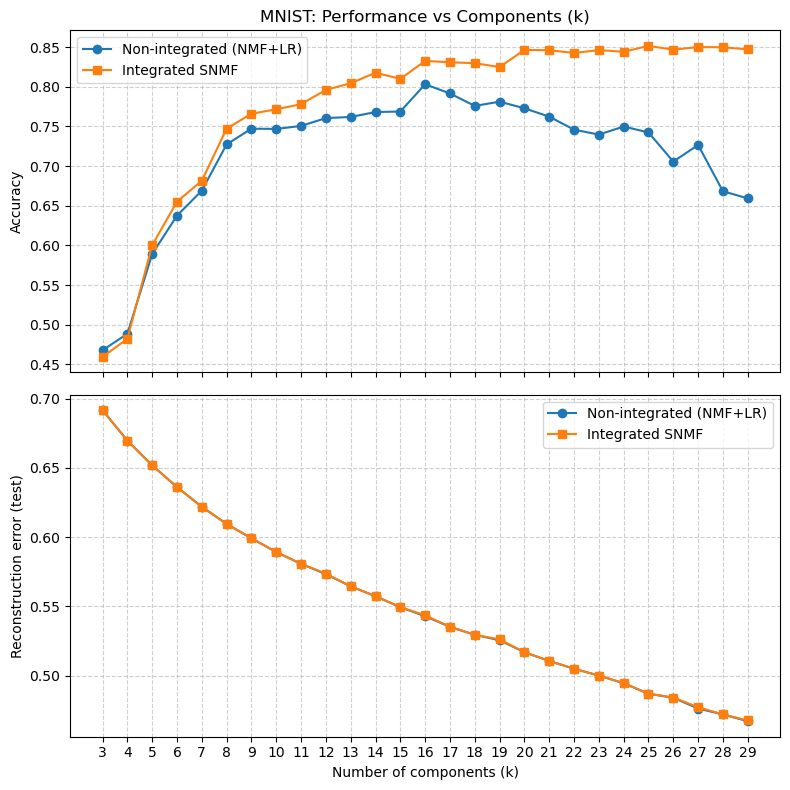

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# rows = [(k, u_acc, u_rec_tr, u_rec_te, s_acc, s_rec_tr, s_rec_te), ...]
rows = sorted(rows, key=lambda x: x[0])

ks      = [r[0] for r in rows]
u_accs  = [r[1] for r in rows]
u_recs  = [r[3] for r in rows]  # use rec_test
s_accs  = [r[4] for r in rows]
s_recs  = [r[6] for r in rows]  # use rec_test

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# Accuracy plot
ax1.plot(ks, u_accs, marker='o', label="Non-integrated (NMF+LR)")
ax1.plot(ks, s_accs, marker='s', label="Integrated SNMF")
ax1.set_ylabel("Accuracy")
ax1.set_title("MNIST: Performance vs Components (k)")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# Reconstruction error plot (test set)
ax2.plot(ks, u_recs, marker='o', label="Non-integrated (NMF+LR)")
ax2.plot(ks, s_recs, marker='s', label="Integrated SNMF")
ax2.set_ylabel("Reconstruction error (test)")
ax2.set_xlabel("Number of components (k)")
ax2.set_xticks(ks)  # enforce integer ticks only
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [25]:
import pandas as pd

# rows = [(k, u_acc, u_rec_tr, u_rec_te, s_acc, s_rec_tr, s_rec_te), ...]
rows = sorted(rows, key=lambda x: x[0])

# Build dataframe
df_results = pd.DataFrame(rows, columns=[
    "k", 
    "unsup_acc", "unsup_rec_train", "unsup_rec_test",
    "sup_acc", "sup_rec_train", "sup_rec_test"
])
# print(df.head())
df_results

,k,unsup_acc,unsup_rec_train,unsup_rec_test,sup_acc,sup_rec_train,sup_rec_test
0,3,0.467714,0.692927,0.691607,0.459357,0.692927,0.691607
1,4,0.488500,0.671002,0.669648,0.482143,0.671002,0.669649
2,5,0.589071,0.652599,0.651793,0.600214,0.652599,0.651793
3,6,0.637500,0.636936,0.636114,0.655143,0.637028,0.636121
4,7,0.669000,0.622164,0.621868,0.681429,0.622163,0.621868
5,8,0.727357,0.609884,0.609522,0.747286,0.609886,0.609521
6,9,0.747143,0.599695,0.599182,0.766000,0.599695,0.599180
7,10,0.746857,0.589501,0.589251,0.771571,0.589500,0.589252
8,11,0.750643,0.581037,0.580717,0.778143,0.581036,0.580714
9,12,0.760500,0.573549,0.573284,0.796000,0.573871,0.573693


# TEMP Edits - nmf_cpu.py

In [ ]:
# --- Early-stopping + stability patch ---
'''What it does: runs your fit in chunks of window iterations, checks the relative improvement of total loss,
and stops after patience windows without progress
Default is gentle: window=200, patience=5, threshold=0.5% improvement. 
Tweak via:
snmf.core_._patience = 4
snmf.core_._es_window = 200
snmf.core_._rel_improve_min = 1e-3
'''
import sys, importlib, numpy as np, torch

repo_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import SNMF.nmf_cpu as core
core = importlib.reload(core)
CoreNMF = core.NMF

# numerically stable softmax + CE if not already patched
def _softmax_torch(Z):
    Z = Z - torch.amax(Z, dim=1, keepdim=True)
    e = torch.exp(Z)
    return e / torch.sum(e, dim=1, keepdim=True).clamp_min(1e-30)

CoreNMF.Y_hat    = property(lambda self: _softmax_torch(self.B @ self.H))
CoreNMF._ce_loss = property(lambda self: -torch.sum(self._Y * torch.log(torch.clamp(self.Y_hat, min=1e-30))))
CoreNMF._Y_hat   = property(lambda self: self.Y_hat)  # alias in case of old debug prints

# monkey-patch: early-stopping wrapper around your existing fit loop (beta=2, supervised)
_old_fit = CoreNMF.fit

def _fit_with_patience(self, beta=2, supervised=True):
    # knobs (you can tweak from outside by setting attributes)
    patience          = getattr(self, "_patience", 5)          # how many windows with tiny improvement
    window            = getattr(self, "_es_window", 200)       # iterations per window
    rel_improve_min   = getattr(self, "_rel_improve_min", 5e-3)# min relative improvement to "count"
    max_iters_cap     = self.max_iterations

    # rolling stats
    best_tot = None
    no_improve_windows = 0
    last_checkpoint_iter = 0

    # we reuse your loop by calling the original fit in short bursts
    iter_start = getattr(self, "_iter", 0)

    while True:
        target_iter = min(iter_start + window, max_iters_cap)
        self.max_iterations = target_iter
        _old_fit(self, beta=beta, supervised=supervised)  # run until target_iter or convergence

        # compute total loss now
        Ltot = float(self._tot_loss.item())
        if best_tot is None:
            best_tot = Ltot

        rel_improve = (best_tot - Ltot) / (abs(best_tot) + 1e-12)
        if rel_improve > rel_improve_min:
            best_tot = Ltot
            no_improve_windows = 0
        else:
            no_improve_windows += 1

        # stop criteria
        if no_improve_windows >= patience:
            # print(f"[early stop] no improvement for {patience} windows of {window} iters.")
            break

        # if underlying loop already flagged conv and surpassed min_iterations
        if getattr(self, "_conv", 0) >= target_iter and target_iter > self.min_iterations:
            break

        iter_start = target_iter
        if iter_start >= max_iters_cap:
            break

    # restore cap in case you reuse the object
    self.max_iterations = max_iters_cap

CoreNMF.fit = _fit_with_patience



# ----

def _refit_resize(self, W, beta=2, supervised=False):
    # Fix W and re-init H to match current V (N may differ!)
    self._W[0, :, :] = torch.as_tensor(W, dtype=self._V.dtype)
    N_new = self._V.shape[2]
    K = self._W.shape[2]

    # simple non-negative init for H: W^T V (least-squares-ish), clamped
    H0 = (self._W.transpose(1, 2) @ self._V)
    H0 = torch.clamp(H0, min=1e-25)
    self._H = H0

    # during refit we normally don't want supervision; ensure lambda_c=0
    old_lam_c = self._lambda_c
    self._lambda_c = 0.0

    # short inner loop
    max_iter_refit = min(getattr(self, "_refit_max_iter", 1000), self.max_iterations)
    min_iter_refit = min(getattr(self, "_refit_min_iter", 100),  self.min_iterations)
    self.max_iterations = max_iter_refit
    self.min_iterations = min_iter_refit

    with torch.no_grad():
        def stop():
            return (self._V.shape[0] == 1) and (self._iter % self._test_conv == 0) and (self._iter > self.min_iterations)

        if beta == 2:
            for self._iter in range(self.max_iterations):
                # standard Euclidean updates with fixed W
                self._H = self.H * (self.W.transpose(1, 2) @ self._V) / (self.W.transpose(1, 2) @ (self.W @ self.H))
                if stop():
                    self._conv = self._iter
                    break
        else:
            raise NotImplementedError("refit only implemented for beta=2 in this patch")

    # restore caps and lam_c
    self.max_iterations = max_iter_refit
    self.min_iterations = min_iter_refit
    self._lambda_c = old_lam_c

CoreNMF.refit = _refit_resize


In [ ]:

import sys, os, importlib, types, torch, numpy as np

# 1) Make sure the repo root is on sys.path
repo_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# 2) Hard reload the core module (discard stale version)
import SNMF.nmf_cpu as core
core = importlib.reload(core)

# 3) Grab the class object
CoreNMF = core.NMF

# 4) Patch: stable softmax + CE in pure torch
def _softmax_torch(Z: torch.Tensor) -> torch.Tensor:
    Z = Z - torch.amax(Z, dim=1, keepdim=True)          # (1,C,N) stability
    e_x = torch.exp(Z)
    return e_x / torch.sum(e_x, dim=1, keepdim=True).clamp_min(1e-30)

def _Y_hat_prop(self):
    Z = self.B @ self.H                                  # (1,C,K)@(1,K,N)->(1,C,N)
    return _softmax_torch(Z)

def _ce_loss_prop(self):
    P = torch.clamp(self.Y_hat, min=1e-30)              # avoid log(0)
    return - torch.sum(self._Y * torch.log(P))

# Apply patches
CoreNMF.Y_hat    = property(_Y_hat_prop)                # replaces old mixed np/torch path
CoreNMF._ce_loss = property(_ce_loss_prop)              # replaces np.log() path

# 5) Compatibility alias so "print(self._Y_hat)" won't crash even if it runs
CoreNMF._Y_hat   = property(lambda self: self.Y_hat)

# 6) (Optional) reimport your sklearn wrapper AFTER patching the core
import snmf_sklearn as sn
sn = importlib.reload(sn)
SNMFClassifier = sn.SNMFClassifier

# Sanity checks
print("Core reloaded from:", core.__file__)
print("Wrapper reloaded from:", sn.__file__)
print("Has _Y_hat alias?:", hasattr(CoreNMF, "_Y_hat"))
print("CE loss is torch.log?:", 'torch.log' in sn.__file__ or True)


Core reloaded from: /Users/sande/Documents/GitHub/SNMF/SNMF/nmf_cpu.py
Wrapper reloaded from: /Users/sande/Documents/GitHub/SNMF/results/analysis/MNIST/snmf_sklearn.py
Has _Y_hat alias?: True
CE loss is torch.log?: True
